In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import simpy

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

LAMBDA1 = 3.0
LAMBDA2 = 5.0
MU = 10.0
print("lambda1, lambda2, mu:", LAMBDA1, LAMBDA2, MU)

lambda1, lambda2, mu: 3.0 5.0 10.0


In [2]:
def mm1_np_priority_metrics(lambda1: float, lambda2: float, mu: float) -> dict | None:
    lam = lambda1 + lambda2
    rho1 = lambda1 / mu
    rho2 = lambda2 / mu
    rho = rho1 + rho2
    if rho >= 1.0:
        return None

    residual_term = lam / (mu ** 2)

    wq1 = residual_term / (1.0 - rho1)
    wq2 = residual_term / ((1.0 - rho1) * (1.0 - rho))

    w1 = wq1 + 1.0 / mu
    w2 = wq2 + 1.0 / mu

    l1 = lambda1 * w1
    l2 = lambda2 * w2
    l_tot = l1 + l2


    p_wait1_theory = rho

    return {
        "lambda1": lambda1,
        "lambda2": lambda2,
        "mu": mu,
        "rho1": rho1,
        "rho2": rho2,
        "rho": rho,
        "Wq1": wq1,
        "Wq2": wq2,
        "W1": w1,
        "W2": w2,
        "L1": l1,
        "L2": l2,
        "L": l_tot,
        "P_wait1_theory": p_wait1_theory,
    }


base = mm1_np_priority_metrics(LAMBDA1, LAMBDA2, MU)
print(pd.Series(base))

lambda1            3.000000
lambda2            5.000000
mu                10.000000
rho1               0.300000
rho2               0.500000
rho                0.800000
Wq1                0.114286
Wq2                0.571429
W1                 0.214286
W2                 0.671429
L1                 0.642857
L2                 3.357143
L                  4.000000
P_wait1_theory     0.800000
dtype: float64


In [3]:
rows = []
if base is not None:
    rows.append(
        {
            "класс": "1 (высокий)",
            "Wq": base["Wq1"],
            "W": base["W1"],
            "P_wait (теор., прибл.)": base["P_wait1_theory"],
            "L": base["L1"],
        }
    )
    rows.append(
        {
            "класс": "2 (низкий)",
            "Wq": base["Wq2"],
            "W": base["W2"],
            "P_wait (теор., прибл.)": base["rho"],
            "L": base["L2"],
        }
    )
df_theory_classes = pd.DataFrame(rows)
df_system = pd.DataFrame([{"rho": base["rho"], "L (вся система)": base["L"]}])

print("Теория по классам:")
print(df_theory_classes)
print("Система:")
print(df_system)

Теория по классам:
         класс        Wq         W  P_wait (теор., прибл.)         L
0  1 (высокий)  0.114286  0.214286                     0.8  0.642857
1   2 (низкий)  0.571429  0.671429                     0.8  3.357143
Система:
   rho  L (вся система)
0  0.8              4.0


In [4]:
def simulate_mm1_np_priority(
    lambda1: float,
    lambda2: float,
    mu: float,
    sim_time: float = 80_000.0,
    warmup: float = 8_000.0,
    seed: int = 42,
) -> dict:
    env = simpy.Environment()
    server = simpy.PriorityResource(env, capacity=1)
    rng = np.random.default_rng(seed)

    stats = {
        "n1": 0,
        "n2": 0,
        "waited1": 0,
        "waited2": 0,
        "sum_wq1": 0.0,
        "sum_wq2": 0.0,
        "sum_w1": 0.0,
        "sum_w2": 0.0,
    }

    def customer(class_id: int):
        arrival = env.now
        pr = 1 if class_id == 1 else 2
        with server.request(priority=pr) as req:
            yield req
            wait = env.now - arrival
            yield env.timeout(rng.exponential(1.0 / mu))

        if arrival < warmup:
            return
        if class_id == 1:
            stats["n1"] += 1
            stats["sum_wq1"] += wait
            stats["sum_w1"] += env.now - arrival
            if wait > 1e-12:
                stats["waited1"] += 1
        else:
            stats["n2"] += 1
            stats["sum_wq2"] += wait
            stats["sum_w2"] += env.now - arrival
            if wait > 1e-12:
                stats["waited2"] += 1

    def arrivals_class(lam: float, class_id: int):
        while True:
            yield env.timeout(rng.exponential(1.0 / lam))
            env.process(customer(class_id))

    env.process(arrivals_class(lambda1, 1))
    env.process(arrivals_class(lambda2, 2))
    env.run(until=sim_time)

    n1, n2 = stats["n1"], stats["n2"]
    return {
        "Wq1": stats["sum_wq1"] / n1 if n1 else np.nan,
        "Wq2": stats["sum_wq2"] / n2 if n2 else np.nan,
        "W1": stats["sum_w1"] / n1 if n1 else np.nan,
        "W2": stats["sum_w2"] / n2 if n2 else np.nan,
        "P_wait1": stats["waited1"] / n1 if n1 else np.nan,
        "P_wait2": stats["waited2"] / n2 if n2 else np.nan,
        "n1": n1,
        "n2": n2,
    }

sim_base = simulate_mm1_np_priority(LAMBDA1, LAMBDA2, MU, sim_time=80_000, warmup=8_000, seed=42)
th = mm1_np_priority_metrics(LAMBDA1, LAMBDA2, MU)

compare = pd.DataFrame(
    {
        "metric": ["Wq1", "Wq2", "W1", "W2", "P_wait1", "P_wait2"],
        "theory": [th["Wq1"], th["Wq2"], th["W1"], th["W2"], th["P_wait1_theory"], th["rho"]],
        "simulation": [
            sim_base["Wq1"],
            sim_base["Wq2"],
            sim_base["W1"],
            sim_base["W2"],
            sim_base["P_wait1"],
            sim_base["P_wait2"],
        ],
    }
)
compare["abs_err"] = (compare["simulation"] - compare["theory"]).abs()
compare["rel_err_%"] = np.where(
    np.isfinite(compare["theory"]) & (compare["theory"] != 0),
    compare["abs_err"] / np.abs(compare["theory"]) * 100.0,
    np.nan,
)

print("Заявок после warmup: класс 1 =", sim_base["n1"], ", класс 2 =", sim_base["n2"])
print(compare)

Заявок после warmup: класс 1 = 215944 , класс 2 = 361221
    metric    theory  simulation   abs_err  rel_err_%
0      Wq1  0.114286    0.114707  0.000421   0.368368
1      Wq2  0.571429    0.586928  0.015500   2.712445
2       W1  0.214286    0.214796  0.000511   0.238366
3       W2  0.671429    0.686811  0.015383   2.291031
4  P_wait1  0.800000    0.801018  0.001018   0.127232
5  P_wait2  0.800000    0.801479  0.001479   0.184859


In [5]:
def sweep_lambda1(lambda2_fixed: float, mu: float, grid):
    rows = []
    for i, l1 in enumerate(grid):
        if l1 < 0:
            continue
        t = mm1_np_priority_metrics(l1, lambda2_fixed, mu)
        if t is None:
            continue
        s = simulate_mm1_np_priority(l1, lambda2_fixed, mu, sim_time=25_000, warmup=3_000, seed=500 + i)
        rows.append(
            {
                "lambda1": l1,
                "Wq1_theory": t["Wq1"],
                "Wq2_theory": t["Wq2"],
                "Wq1_sim": s["Wq1"],
                "Wq2_sim": s["Wq2"],
                "rho": t["rho"],
            }
        )
    return pd.DataFrame(rows)


def sweep_lambda2(lambda1_fixed: float, mu: float, grid):
    rows = []
    for i, l2 in enumerate(grid):
        if l2 < 0:
            continue
        t = mm1_np_priority_metrics(lambda1_fixed, l2, mu)
        if t is None:
            continue
        s = simulate_mm1_np_priority(lambda1_fixed, l2, mu, sim_time=25_000, warmup=3_000, seed=700 + i)
        rows.append(
            {
                "lambda2": l2,
                "Wq1_theory": t["Wq1"],
                "Wq2_theory": t["Wq2"],
                "Wq1_sim": s["Wq1"],
                "Wq2_sim": s["Wq2"],
                "rho": t["rho"],
            }
        )
    return pd.DataFrame(rows)

g1 = np.linspace(0.1, 4.5, 12)
df_s1 = sweep_lambda1(LAMBDA2, MU, g1)

g2 = np.linspace(0.1, 4.5, 12)
df_s2 = sweep_lambda2(LAMBDA1, MU, g2)
print("Сетка по λ1 (первые строки):")
print(df_s1.head())
print("Сетка по λ2 (первые строки):")
print(df_s2.head())

Сетка по λ1 (первые строки):
   lambda1  Wq1_theory  Wq2_theory   Wq1_sim   Wq2_sim   rho
0      0.1    0.051515    0.105133  0.050054  0.106421  0.51
1      0.5    0.057895    0.128655  0.055788  0.125684  0.55
2      0.9    0.064835    0.158135  0.063846  0.152927  0.59
3      1.3    0.072414    0.195713  0.074608  0.202542  0.63
4      1.7    0.080723    0.244615  0.080491  0.248531  0.67
Сетка по λ2 (первые строки):
   lambda2  Wq1_theory  Wq2_theory   Wq1_sim   Wq2_sim   rho
0      0.1    0.044286    0.064182  0.044157  0.056949  0.31
1      0.5    0.050000    0.076923  0.049930  0.075033  0.35
2      0.9    0.055714    0.091335  0.056071  0.090846  0.39
3      1.3    0.061429    0.107769  0.060917  0.104669  0.43
4      1.7    0.067143    0.126685  0.066429  0.125723  0.47


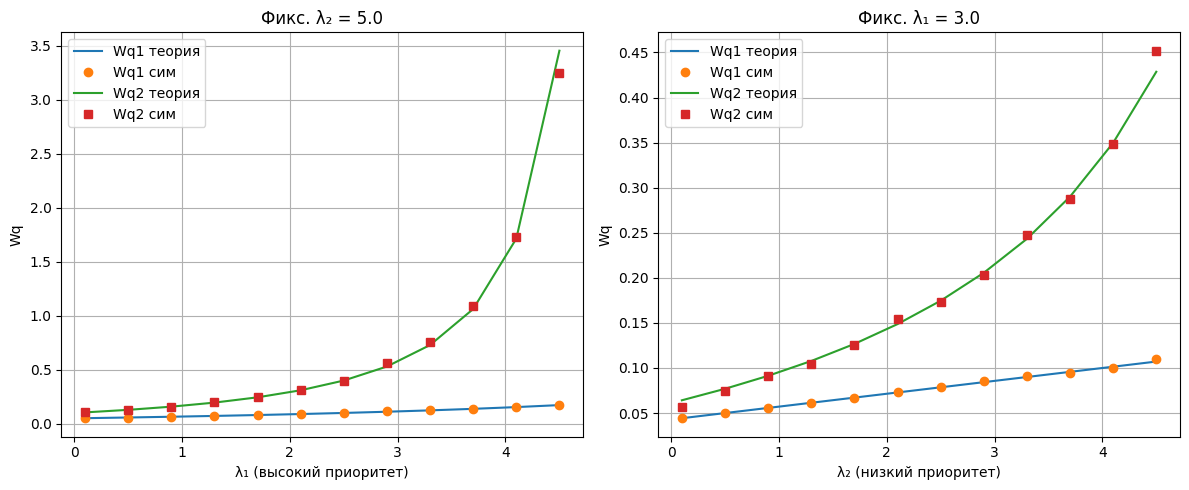

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(df_s1["lambda1"], df_s1["Wq1_theory"], "-", label="Wq1 теория")
ax[0].plot(df_s1["lambda1"], df_s1["Wq1_sim"], "o", label="Wq1 сим")
ax[0].plot(df_s1["lambda1"], df_s1["Wq2_theory"], "-", label="Wq2 теория")
ax[0].plot(df_s1["lambda1"], df_s1["Wq2_sim"], "s", label="Wq2 сим")
ax[0].set_xlabel("λ₁ (высокий приоритет)")
ax[0].set_ylabel("Wq")
ax[0].set_title(f"Фикс. λ₂ = {LAMBDA2}")
ax[0].legend()

ax[1].plot(df_s2["lambda2"], df_s2["Wq1_theory"], "-", label="Wq1 теория")
ax[1].plot(df_s2["lambda2"], df_s2["Wq1_sim"], "o", label="Wq1 сим")
ax[1].plot(df_s2["lambda2"], df_s2["Wq2_theory"], "-", label="Wq2 теория")
ax[1].plot(df_s2["lambda2"], df_s2["Wq2_sim"], "s", label="Wq2 сим")
ax[1].set_xlabel("λ₂ (низкий приоритет)")
ax[1].set_ylabel("Wq")
ax[1].set_title(f"Фикс. λ₁ = {LAMBDA1}")
ax[1].legend()

plt.tight_layout()
plt.show()